# 🏦 MVP — Optimización Operativa de Personal Bancario
## Modelo M/M/s | Dotación óptima por hora y turno

**Objetivo:** Determinar la dotación óptima de auxiliares de operaciones por agencia y franja horaria, minimizando costos y cumpliendo las restricciones operativas del negocio.

---
### ⚠️ Alcance del MVP
- ✅ Modelo M/M/s reutilizado del Modelo v4 (sin reescritura)
- ✅ Optimización de servidores por hora y turno
- ✅ Clasificación de estado operativo
- ✅ Insights gerenciales y recomendaciones accionables
- ❌ M/G/s (excluido)
- ❌ Simulación Monte Carlo (excluida)
- ❌ Análisis de sensibilidad (excluido)

### 📏 Restricciones obligatorias
| Restricción | Umbral | Consecuencia si viola |
|---|---|---|
| Utilización ρ = λ/(s×μ) | < 0.85 | Penalización por inestabilidad |
| Tiempo de espera Wq | < 5 min | Nivel de servicio inaceptable |
| Estabilidad del sistema | ρ < 1 | Sistema inviable |

### 🔁 Flujo del MVP
```
Datos (df.csv + dist_agencias.csv)
  → μ ponderado por mezcla de operaciones
    → Modelo M/M/s (REUTILIZADO de v4)
      → Optimización: encontrar s_óptimo mínimo que cumple restricciones
        → Clasificación de estado (Óptimo / Sobredimensionado / Subdimensionado / Crítico)
          → DataFrame final + CSV para Power BI
            → Visualizaciones gerenciales + Insights
```

---
## PASO 1 — Librerías y configuración global

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import warnings
from math import factorial

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 220)

# ── Parámetros globales del modelo ───────────────────────────────────────────
WQ_MAX_MIN  = 5.0    # Wq máximo aceptable (minutos)
RHO_MAX     = 0.85   # Utilización máxima operativa
MAX_SERVERS = 15     # Tope de búsqueda en optimización

# ── Paleta de colores por estado ─────────────────────────────────────────────
COLOR_MAP = {
    'Óptimo':           '#2ecc71',
    'Sobredimensionado': '#3498db',
    'Subdimensionado':   '#e74c3c',
    'Crítico':           '#8e44ad'
}

# ── Estilo visual ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#64748b',
    'ytick.color':      '#64748b',
    'text.color':       '#e2e8f0',
    'grid.color':       '#1e293b',
    'grid.linestyle':   '--',
    'grid.alpha':       0.4,
    'axes.titlecolor':  '#f1f5f9',
    'axes.titlesize':   12,
    'axes.titleweight': 'bold',
    'legend.facecolor': '#1e293b',
    'legend.edgecolor': '#334155',
    'legend.labelcolor':'#94a3b8',
    'font.family':      'monospace',
})

print('✅ Configuración cargada')
print(f'   Wq_max = {WQ_MAX_MIN} min  |  ρ_max = {RHO_MAX}  |  s_max = {MAX_SERVERS}')

✅ Configuración cargada
   Wq_max = 5.0 min  |  ρ_max = 0.85  |  s_max = 15


---
## PASO 2 — Carga de datos

In [18]:
df   = pd.read_csv('df.csv')
dist = pd.read_csv('dist_agencias.csv')
cols_horas = [c for c in dist.columns if ':' in c]
agencias   = df['agencia'].unique()

print(f'✅ df.csv:   {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'✅ dist.csv: {dist.shape[0]} filas × {len(cols_horas)} franjas horarias')
print(f'   Agencias: {", ".join(agencias)}')
print()
print(df.to_string(index=False))

✅ df.csv:   30 filas × 6 columnas
✅ dist.csv: 18 filas × 10 franjas horarias
   Agencias: AG.PARQUE DE LAS FLORES LOS GUINDALES, AG. CIUDAD UNIVERSITARIA, AG. OPEN SAN CARLOS

                              agencia                hora  lambda  servidores      Cs      Cq
AG.PARQUE DE LAS FLORES LOS GUINDALES 09:00:00 - 09:59:59 50.5000           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 10:00:00 - 10:59:59 60.1200           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 11:00:00 - 11:59:59 58.9000           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 12:00:00 - 12:59:59 43.4800           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 13:00:00 - 13:59:59 35.0000           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 14:00:00 - 14:59:59 31.6400           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 15:00:00 - 15:59:59 44.2300           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 16:00:00 - 16:59:59 59.1100       

---
## PASO 3 — Parámetros de servicio y cálculo de μ ponderado

### ¿Por qué μ varía por hora?
La mezcla de operaciones cambia a lo largo del día. Una hora con más desembolsos (14.5 min promedio) tiene un μ menor que una hora dominada por depósitos (2.8 min). Por eso calculamos μ como la media ponderada de los tiempos por tipo de operación:

```
E[T] = Σ p_k(hora) × t_k     →     μ = 60 / E[T]
```

In [19]:
# Tiempo promedio de servicio por tipo de operación (minutos)
T_SERVICIO = {
    'DEPOSITO':                         3.8,
    'COBRANZA LOCALES OTRAS AGENCIAS':  3.5,
    'COBRANZAS':                        3.5,
    'RETIRO':                           3.0,
    'DESEMBOLSO':                      20.5,
    'APERTURA':                        12.0
}

dist['t_s'] = dist['tipo_ope'].map(T_SERVICIO)


def calcular_mu(df_base, dist_df, cols_horas):
    """
    Calcula μ ponderado por la mezcla de operaciones de cada (agencia, hora).
    Reutilizado del Modelo v4 — sin modificación.
    """
    rows = []
    for _, row in df_base.iterrows():
        agencia = row['agencia']
        hora    = row['hora']
        d       = dist_df[dist_df['agencia'] == agencia]

        if hora not in d.columns:
            rows.append({'agencia': agencia, 'hora': hora, 'mu': np.nan})
            continue

        probs = d[hora].values.astype(float)
        ts    = d['t_s'].values.astype(float)
        total = probs.sum()

        if total == 0 or np.isnan(total):
            rows.append({'agencia': agencia, 'hora': hora, 'mu': np.nan})
            continue

        E_T = np.dot(probs, ts) / total
        mu  = 60.0 / E_T if E_T > 0 else np.nan
        rows.append({'agencia': agencia, 'hora': hora, 'mu': mu})

    return pd.DataFrame(rows)


mu_df = calcular_mu(df, dist, cols_horas)
df2   = df.merge(mu_df, on=['agencia', 'hora'], how='left')

print('μ calculado por agencia-hora:')
print(df2[['agencia', 'hora', 'lambda', 'mu', 'servidores']].to_string(index=False))

μ calculado por agencia-hora:
                              agencia                hora  lambda      mu  servidores
AG.PARQUE DE LAS FLORES LOS GUINDALES 09:00:00 - 09:59:59 50.5000 13.5202           5
AG.PARQUE DE LAS FLORES LOS GUINDALES 10:00:00 - 10:59:59 60.1200 13.0541           5
AG.PARQUE DE LAS FLORES LOS GUINDALES 11:00:00 - 11:59:59 58.9000 12.9096           5
AG.PARQUE DE LAS FLORES LOS GUINDALES 12:00:00 - 12:59:59 43.4800 12.4173           5
AG.PARQUE DE LAS FLORES LOS GUINDALES 13:00:00 - 13:59:59 35.0000 12.5840           5
AG.PARQUE DE LAS FLORES LOS GUINDALES 14:00:00 - 14:59:59 31.6400 12.7581           5
AG.PARQUE DE LAS FLORES LOS GUINDALES 15:00:00 - 15:59:59 44.2300 13.1346           5
AG.PARQUE DE LAS FLORES LOS GUINDALES 16:00:00 - 16:59:59 59.1100 12.9735           5
AG.PARQUE DE LAS FLORES LOS GUINDALES 17:00:00 - 17:59:59 65.2800 11.8197           5
AG.PARQUE DE LAS FLORES LOS GUINDALES 18:00:00 - 18:59:59 23.4500  9.6320           5
             AG. CIUDAD 

---
## PASO 4 — Modelo M/M/s (REUTILIZADO del Modelo v4)

> ⚠️ **Esta función es idéntica a la del Modelo v4. No se reescribe ni se modifica.**

### Fórmulas del modelo M/M/s
```
ρ  = λ / (s × μ)                               ← utilización

P₀ = 1 / [ Σk=0..s-1(r^k/k!) + r^s/(s!(1-ρ)) ]  donde r = λ/μ

Lq = P₀ × r^s × ρ / (s! × (1-ρ)²)             ← clientes en cola

Wq = Lq / λ   (en horas)  →  Wq_min = Wq × 60

Ws = Wq + 1/μ             Ls = λ × Ws

CT = (Cs+Cq)×(Ls-Lq) + Cs×ociosos + λ×Cq×Wq
```

In [20]:
def mms_metricas(lam, mu, s, Cs=0, Cq=0):
    """
    ══════════════════════════════════════════════════════════════════
    MODELO M/M/s — REUTILIZADO DEL MODELO v4 (sin modificación)
    ══════════════════════════════════════════════════════════════════
    Parámetros:
      lam : tasa de llegadas (clientes/hora)
      mu  : tasa de servicio por servidor (clientes/hora)
      s   : número de servidores
      Cs  : costo por servidor activo (S/./hora)
      Cq  : costo de espera por cliente (S/./hora)
    Retorna:
      dict con todas las métricas, o None si parámetros inválidos
    """
    nan_r = dict(rho=np.nan, P0=np.nan, Lq=np.nan, Wq_h=np.nan,
                 Ws_h=np.nan, Ls=np.nan, Wq_m=np.nan, Ws_m=np.nan,
                 serv_ocupados=np.nan, serv_ociosos=np.nan, CT=np.nan, valido=False)

    if mu <= 0 or s <= 0 or lam < 0:
        return nan_r

    s   = int(s)
    rho = lam / (s * mu)
    r   = lam / mu

    if rho >= 1:
        return {**nan_r, 'rho': rho, 'valido': False}

    # Probabilidad de sistema vacío
    sum_k  = sum(r**k / factorial(k) for k in range(s))
    term_s = (r**s) / (factorial(s) * (1 - rho))
    P0     = 1.0 / (sum_k + term_s)

    # Métricas de cola
    Lq   = P0 * (r**s) * rho / (factorial(s) * (1 - rho)**2)
    Wq_h = Lq / lam if lam > 0 else 0.0
    Ws_h = Wq_h + 1.0 / mu
    Ls   = lam * Ws_h
    Wq_m = Wq_h * 60
    Ws_m = Ws_h * 60

    # Servidores
    serv_ocupados = Ls - Lq
    serv_ociosos  = s - serv_ocupados

    # Costo total
    CT = (Cs + Cq) * serv_ocupados + Cs * max(serv_ociosos, 0) + lam * Cq * Wq_h

    return dict(
        rho=rho, P0=P0, Lq=Lq, Wq_h=Wq_h, Ws_h=Ws_h,
        Ls=Ls, Wq_m=Wq_m, Ws_m=Ws_m,
        serv_ocupados=serv_ocupados, serv_ociosos=serv_ociosos,
        CT=CT, valido=True
    )


# ── Test de verificación ─────────────────────────────────────────────────────
t = mms_metricas(60, 20, 5, 13.64, 27.29)
print('Test M/M/s (λ=60, μ=20, s=5):')
print(f'  ρ     = {t["rho"]:.4f}')
print(f'  Wq    = {t["Wq_m"]:.4f} min')
print(f'  CT    = S/.{t["CT"]:.2f}')
print(f'  Válido= {t["valido"]}')
print()
print('✅ Modelo M/M/s listo (reutilizado del v4 sin modificación)')

Test M/M/s (λ=60, μ=20, s=5):
  ρ     = 0.6000
  Wq    = 0.3542 min
  CT    = S/.159.74
  Válido= True

✅ Modelo M/M/s listo (reutilizado del v4 sin modificación)


---
## PASO 5 — Capa de Optimización

**Algoritmo:**  
Para cada (agencia, hora), iterar s de s_min a MAX_SERVERS y encontrar el **mínimo s** que cumpla:
- ρ < 0.85
- Wq ≤ 5 min

Si no existe tal s → clasificar como **Crítico**.

In [21]:
def optimizar_servidores(lam, mu, Cs, Cq, s_max=MAX_SERVERS):
    """
    Capa de optimización sobre el modelo M/M/s existente.
    Busca el mínimo s que cumple: ρ < RHO_MAX y Wq ≤ WQ_MAX_MIN.

    Retorna:
      (s_opt, metricas_opt)  si existe solución factible
      None                   si no existe (caso Crítico)
    """
    if np.isnan(mu) or mu <= 0 or np.isnan(lam) or lam <= 0:
        return None

    # s mínimo para estabilidad del sistema (ρ < 1)
    s_min = max(1, int(np.ceil(lam / mu)) + 1)

    for s in range(s_min, s_max + 1):
        m = mms_metricas(lam, mu, s, Cs, Cq)
        if not m['valido']:
            continue
        # ← Verificar ambas restricciones
        if m['rho'] < RHO_MAX and m['Wq_m'] <= WQ_MAX_MIN:
            return s, m

    return None  # No existe solución factible


def clasificar_estado(row):
    """
    Clasifica el estado operativo comparando s_actual vs s_optimo.

    Estados:
      Óptimo           → s_actual == s_optimo Y cumple restricciones
      Sobredimensionado → s_actual > s_optimo  (exceso de personal, sobrecosto)
      Subdimensionado  → s_actual < s_optimo  (déficit, mala calidad de servicio)
      Crítico          → no existe s factible  (sistema colapsa)
    """
    if pd.isna(row['s_optimo']):
        return 'Crítico'
    diff = row['s_actual'] - row['s_optimo']
    if diff > 0:
        return 'Sobredimensionado'
    elif diff < 0:
        return 'Subdimensionado'
    else:
        return 'Óptimo'


print('✅ Capa de optimización definida')
print(f'   Búsqueda: s ∈ [s_min, {MAX_SERVERS}]')
print(f'   Criterio: ρ < {RHO_MAX}  AND  Wq ≤ {WQ_MAX_MIN} min')

✅ Capa de optimización definida
   Búsqueda: s ∈ [s_min, 15]
   Criterio: ρ < 0.85  AND  Wq ≤ 5.0 min


---
## PASO 6 — Construcción del DataFrame Final

In [22]:
registros = []

for _, row in df2.iterrows():
    lam   = row['lambda']
    mu    = row['mu']
    s_act = int(row['servidores'])
    Cs    = row['Cs']
    Cq    = row['Cq']
    hora  = row['hora'][:5]
    agencia = row['agencia']

    # ── Estado actual con el M/M/s existente ─────────────────────────────────
    m_act   = mms_metricas(lam, mu, s_act, Cs, Cq)
    rho_act = m_act['rho']   if m_act['valido'] else np.nan
    Wq_act  = m_act['Wq_m']  if m_act['valido'] else np.nan
    CT_act  = m_act['CT']    if m_act['valido'] else np.nan

    # ── Optimización: mínimo s que cumple restricciones ──────────────────────
    resultado = optimizar_servidores(lam, mu, Cs, Cq)

    if resultado is not None:
        s_opt, m_opt = resultado
        rho_opt = m_opt['rho']
        Wq_opt  = m_opt['Wq_m']
        CT_opt  = m_opt['CT']
    else:
        s_opt = np.nan
        rho_opt = np.nan
        Wq_opt  = np.nan
        CT_opt  = np.nan

    # ── Métricas derivadas ────────────────────────────────────────────────────
    diff_s     = (s_act - s_opt) if not np.isnan(s_opt) else np.nan
    ahorro_CT  = (CT_act - CT_opt) if not np.isnan(CT_opt) else np.nan
    cap_actual = s_act * mu
    cap_opt    = s_opt * mu if not np.isnan(s_opt) else np.nan

    registros.append(dict(
        agencia              = agencia,
        hora                 = hora,
        lambda_              = lam,
        mu                   = round(mu, 3),
        s_actual             = s_act,
        s_optimo             = int(s_opt) if not np.isnan(s_opt) else np.nan,
        rho_actual           = round(rho_act, 4) if not np.isnan(rho_act) else np.nan,
        rho_optimo           = round(rho_opt, 4) if not np.isnan(rho_opt) else np.nan,
        Wq_actual            = round(Wq_act, 4)  if not np.isnan(Wq_act)  else np.nan,
        Wq_optimo            = round(Wq_opt, 4)  if not np.isnan(Wq_opt)  else np.nan,
        CT_actual            = round(CT_act, 2)   if not np.isnan(CT_act)  else np.nan,
        CT_optimo            = round(CT_opt, 2)   if not np.isnan(CT_opt)  else np.nan,
        diferencia_servidores= int(diff_s)  if not np.isnan(diff_s) else np.nan,
        ahorro_costo         = round(ahorro_CT, 2) if not np.isnan(ahorro_CT) else np.nan,
        capacidad_actual     = round(cap_actual, 2),
        capacidad_optima     = round(cap_opt, 2) if not np.isnan(cap_opt) else np.nan,
        cumple_rho_actual    = 'SÍ' if (not np.isnan(rho_act) and rho_act < RHO_MAX) else 'NO',
        cumple_Wq_actual     = 'SÍ' if (not np.isnan(Wq_act) and Wq_act <= WQ_MAX_MIN) else 'NO',
    ))

df_final = pd.DataFrame(registros)

# Asignar estado operativo
df_final['estado'] = df_final.apply(clasificar_estado, axis=1)

# Asignar turno
def asignar_turno(hora):
    return 'Turno 1 (09-14)' if int(hora[:2]) < 14 else 'Turno 2 (14-18)'

df_final['turno'] = df_final['hora'].apply(asignar_turno)

print('✅ DataFrame final construido:', df_final.shape)
print()
print(df_final[['agencia','hora','lambda_','mu','s_actual','s_optimo',
                'rho_actual','Wq_actual','diferencia_servidores','estado']].to_string(index=False))

✅ DataFrame final construido: (30, 20)

                              agencia  hora  lambda_      mu  s_actual  s_optimo  rho_actual  Wq_actual  diferencia_servidores            estado
AG.PARQUE DE LAS FLORES LOS GUINDALES 09:00  50.5000 13.5200         5         5      0.7470     1.6019                      0            Óptimo
AG.PARQUE DE LAS FLORES LOS GUINDALES 10:00  60.1200 13.0540         5         6      0.9211     9.4390                     -1   Subdimensionado
AG.PARQUE DE LAS FLORES LOS GUINDALES 11:00  58.9000 12.9100         5         6      0.9125     8.3992                     -1   Subdimensionado
AG.PARQUE DE LAS FLORES LOS GUINDALES 12:00  43.4800 12.4170         5         5      0.7003     1.2200                      0            Óptimo
AG.PARQUE DE LAS FLORES LOS GUINDALES 13:00  35.0000 12.5840         5         4      0.5563     0.3985                      1 Sobredimensionado
AG.PARQUE DE LAS FLORES LOS GUINDALES 14:00  31.6400 12.7580         5         4      0.49

---
## PASO 7 — Resumen ejecutivo

In [23]:
total = len(df_final)
dist_estado = df_final['estado'].value_counts()
pct_cumple_rho = (df_final['cumple_rho_actual'] == 'SÍ').mean() * 100
pct_cumple_wq  = (df_final['cumple_Wq_actual']  == 'SÍ').mean() * 100
ahorro_total   = df_final['ahorro_costo'].sum()
exceso_total   = df_final.loc[df_final['diferencia_servidores']>0, 'diferencia_servidores'].sum()
deficit_total  = abs(df_final.loc[df_final['diferencia_servidores']<0, 'diferencia_servidores'].sum())

print('═' * 60)
print('          RESUMEN EJECUTIVO — MVP OPTIMIZACIÓN')
print('═' * 60)
print(f'  Franjas horarias analizadas : {total}')
print(f'  Agencias                    : {df_final["agencia"].nunique()}')
print()
print('  DISTRIBUCIÓN DE ESTADOS:')
for estado, cnt in dist_estado.items():
    pct = cnt/total*100
    print(f'    {estado:<22}: {cnt:2d} franjas ({pct:.0f}%)')
print()
print(f'  CUMPLIMIENTO SLA ρ < 0.85  : {pct_cumple_rho:.0f}%')
print(f'  CUMPLIMIENTO SLA Wq ≤ 5min  : {pct_cumple_wq:.0f}%')
print()
print(f'  Exceso de servidores (total): {exceso_total} puestos')
print(f'  Déficit de servidores (tot) : {deficit_total} puestos')
print(f'  Ahorro potencial total      : S/.{ahorro_total:.2f}/hora')
print('═' * 60)

════════════════════════════════════════════════════════════
          RESUMEN EJECUTIVO — MVP OPTIMIZACIÓN
════════════════════════════════════════════════════════════
  Franjas horarias analizadas : 30
  Agencias                    : 3

  DISTRIBUCIÓN DE ESTADOS:
    Óptimo                : 13 franjas (43%)
    Sobredimensionado     : 10 franjas (33%)
    Subdimensionado       :  7 franjas (23%)

  CUMPLIMIENTO SLA ρ < 0.85  : 80%
  CUMPLIMIENTO SLA Wq ≤ 5min  : 80%

  Exceso de servidores (total): 13 puestos
  Déficit de servidores (tot) : 9 puestos
  Ahorro potencial total      : S/.2934.93/hora
════════════════════════════════════════════════════════════


---
## PASO 8 — Visualizaciones gerenciales

### Gráfico 1: λ vs Capacidad instalada (s × μ)

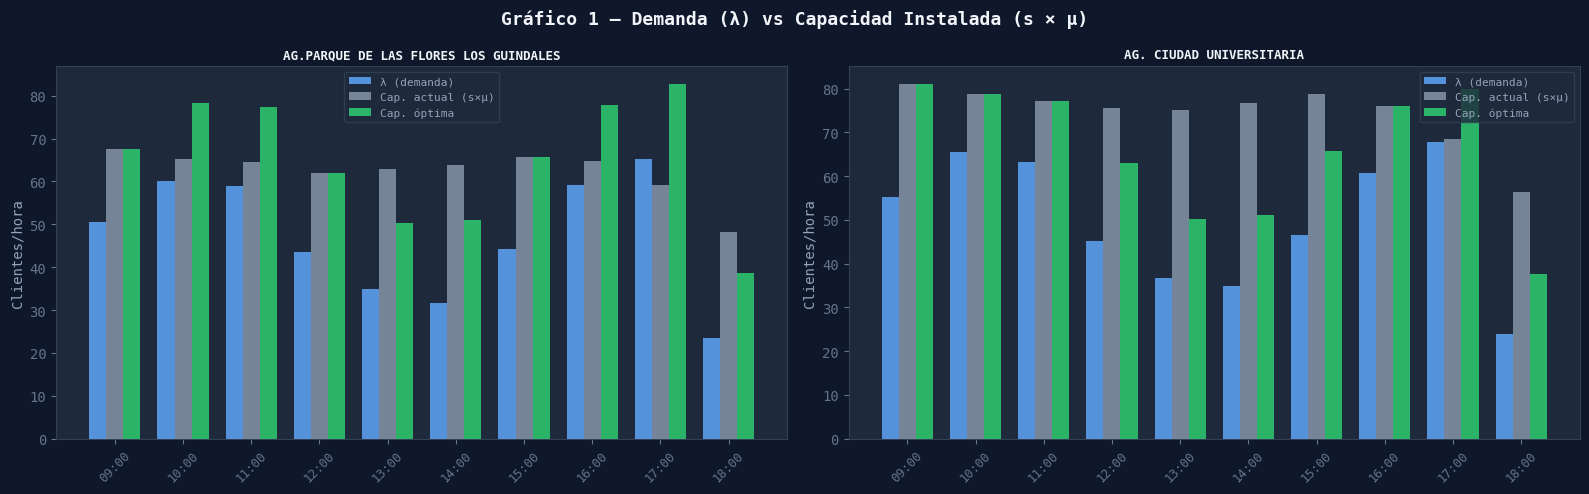

✅ Guardado: g1_lambda_vs_capacidad.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Gráfico 1 — Demanda (λ) vs Capacidad Instalada (s × μ)', fontsize=13, fontweight='bold', color='#f1f5f9')

for ax, agencia in zip(axes, agencias):
    sub   = df_final[df_final['agencia'] == agencia].copy()
    horas = sub['hora'].tolist()
    x     = np.arange(len(horas))

    ax.bar(x - 0.25, sub['lambda_'],          width=0.25, color='#60a5fa', alpha=0.85, label='λ (demanda)',      zorder=3)
    ax.bar(x,        sub['capacidad_actual'],  width=0.25, color='#94a3b8', alpha=0.75, label='Cap. actual (s×μ)', zorder=3)
    ax.bar(x + 0.25, sub['capacidad_optima'],  width=0.25, color='#2ecc71', alpha=0.85, label='Cap. óptima',       zorder=3)

    ax.set_xticks(x); ax.set_xticklabels(horas, rotation=45, fontsize=9)
    ax.set_title(agencia[:38], fontsize=9)
    ax.set_ylabel('Clientes/hora')
    ax.legend(fontsize=8)
    ax.grid(axis='y', zorder=0)

plt.tight_layout()
plt.savefig('g1_lambda_vs_capacidad.png', dpi=130, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print('✅ Guardado: g1_lambda_vs_capacidad.png')

### Gráfico 2: ρ actual vs ρ óptimo (con zona de riesgo)

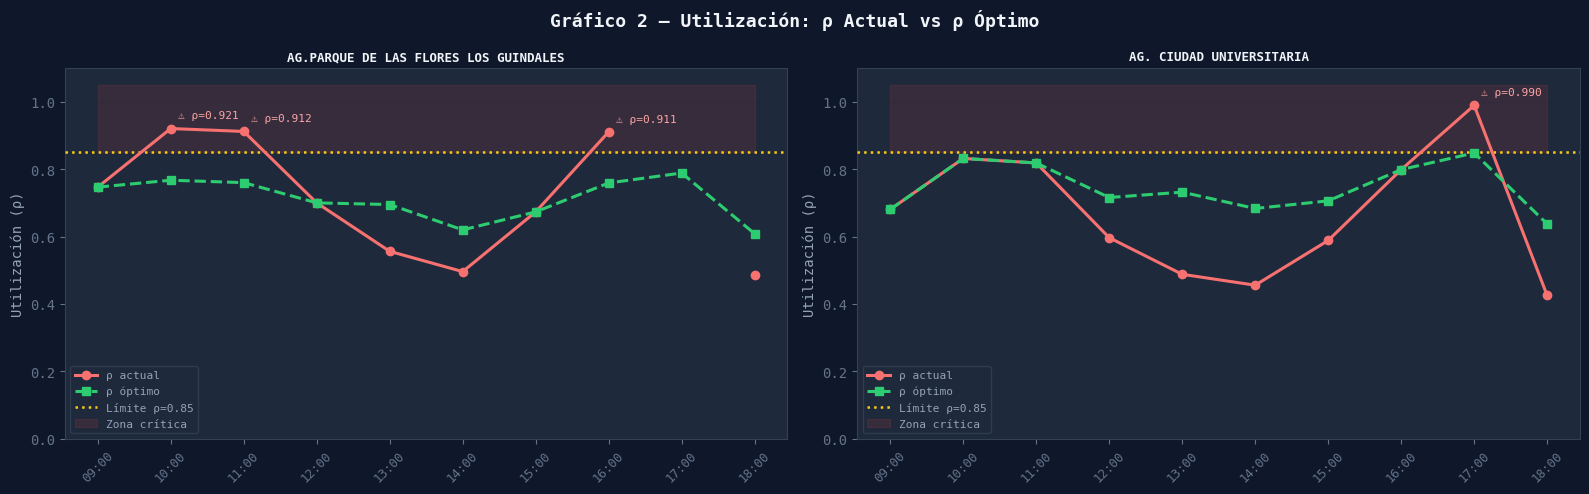

✅ Guardado: g2_rho_actual_vs_optimo.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Gráfico 2 — Utilización: ρ Actual vs ρ Óptimo', fontsize=13, fontweight='bold', color='#f1f5f9')

for ax, agencia in zip(axes, agencias):
    sub   = df_final[df_final['agencia'] == agencia].copy()
    horas = sub['hora'].tolist()
    x     = np.arange(len(horas))

    ax.plot(x, sub['rho_actual'], marker='o', color='#f87171', lw=2.2, label='ρ actual',  zorder=4)
    ax.plot(x, sub['rho_optimo'], marker='s', color='#2ecc71', lw=2.2, label='ρ óptimo',  zorder=4, linestyle='--')

    # Zona de riesgo
    ax.axhline(RHO_MAX, color='#facc15', linestyle=':', lw=1.8, label=f'Límite ρ={RHO_MAX}', zorder=3)
    ax.fill_between(x, RHO_MAX, 1.05, alpha=0.12, color='#ef4444', label='Zona crítica')

    # Anotar violaciones
    for i, (_, r) in enumerate(sub.iterrows()):
        if r['rho_actual'] >= RHO_MAX:
            ax.annotate(f'⚠ ρ={r["rho_actual"]:.3f}', xy=(i, r['rho_actual']),
                       xytext=(i+0.1, r['rho_actual']+0.03),
                       fontsize=8, color='#fca5a5')

    ax.set_xticks(x); ax.set_xticklabels(horas, rotation=45, fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_title(agencia[:38], fontsize=9)
    ax.set_ylabel('Utilización (ρ)')
    ax.legend(fontsize=8)
    ax.grid(axis='y', zorder=0)

plt.tight_layout()
plt.savefig('g2_rho_actual_vs_optimo.png', dpi=130, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print('✅ Guardado: g2_rho_actual_vs_optimo.png')

### Gráfico 3: Wq actual vs línea objetivo (5 minutos)

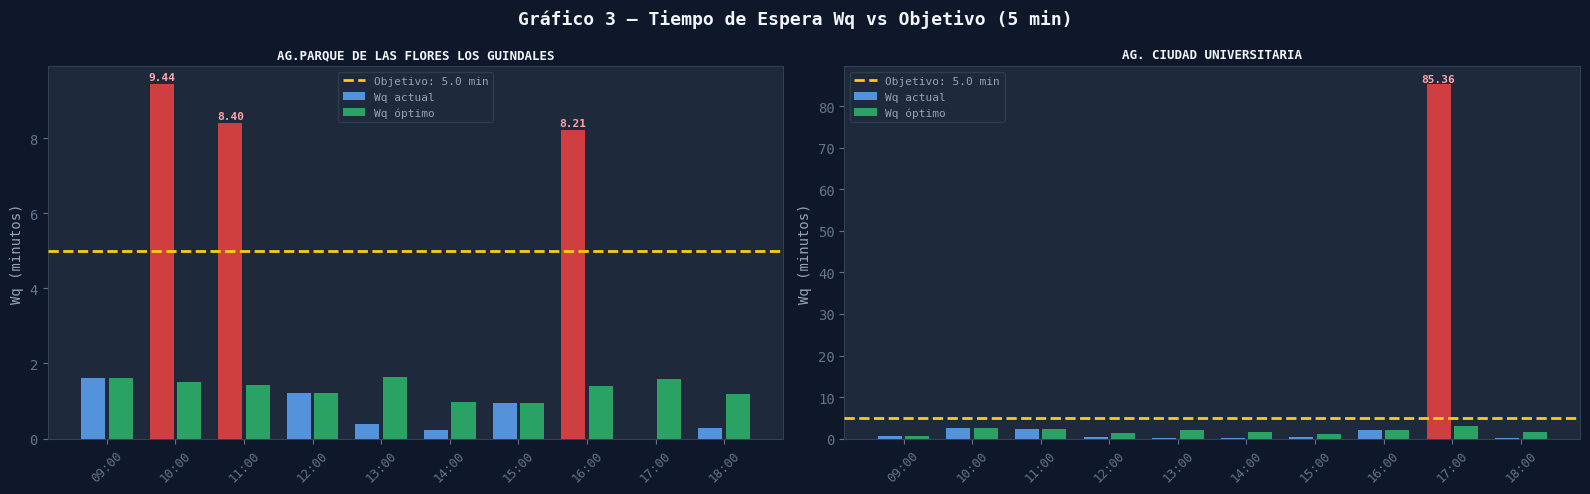

✅ Guardado: g3_wq_vs_objetivo.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Gráfico 3 — Tiempo de Espera Wq vs Objetivo (5 min)', fontsize=13, fontweight='bold', color='#f1f5f9')

for ax, agencia in zip(axes, agencias):
    sub   = df_final[df_final['agencia'] == agencia].copy()
    horas = sub['hora'].tolist()
    x     = np.arange(len(horas))

    # Barras coloreadas por cumplimiento
    colors = ['#ef4444' if w > WQ_MAX_MIN else '#60a5fa' for w in sub['Wq_actual']]
    bars = ax.bar(x - 0.2, sub['Wq_actual'], width=0.35, color=colors, alpha=0.85, label='Wq actual', zorder=3)
    ax.bar(x + 0.2, sub['Wq_optimo'],  width=0.35, color='#2ecc71', alpha=0.75, label='Wq óptimo', zorder=3)

    ax.axhline(WQ_MAX_MIN, color='#facc15', linestyle='--', lw=2, label=f'Objetivo: {WQ_MAX_MIN} min', zorder=4)

    for bar, wq in zip(bars, sub['Wq_actual']):
        if wq > WQ_MAX_MIN:
            ax.text(bar.get_x()+bar.get_width()/2, wq+0.05, f'{wq:.2f}',
                   ha='center', va='bottom', fontsize=8, color='#fca5a5', fontweight='bold')

    ax.set_xticks(x); ax.set_xticklabels(horas, rotation=45, fontsize=9)
    ax.set_title(agencia[:38], fontsize=9)
    ax.set_ylabel('Wq (minutos)')
    ax.legend(fontsize=8)
    ax.grid(axis='y', zorder=0)

plt.tight_layout()
plt.savefig('g3_wq_vs_objetivo.png', dpi=130, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print('✅ Guardado: g3_wq_vs_objetivo.png')

### Gráfico 4: Servidores actuales vs óptimos — decisión de dotación

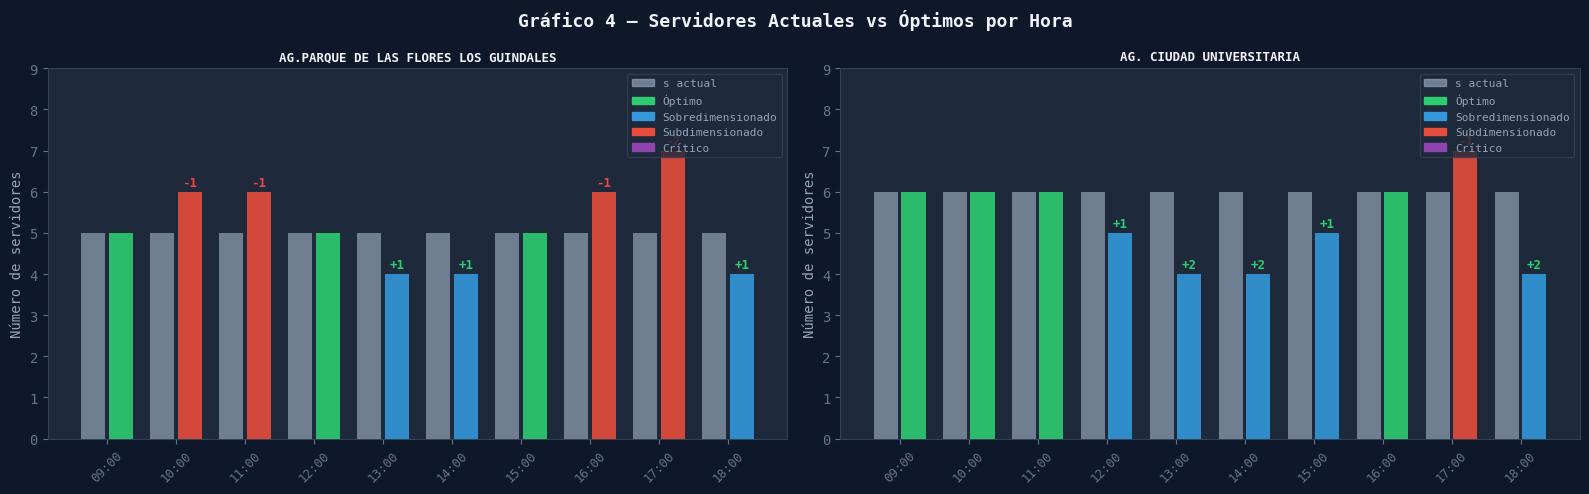

✅ Guardado: g4_servidores_actuales_vs_optimos.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Gráfico 4 — Servidores Actuales vs Óptimos por Hora', fontsize=13, fontweight='bold', color='#f1f5f9')

for ax, agencia in zip(axes, agencias):
    sub   = df_final[df_final['agencia'] == agencia].copy()
    horas = sub['hora'].tolist()
    x     = np.arange(len(horas))
    estado_colors = [COLOR_MAP.get(e, '#94a3b8') for e in sub['estado']]

    ax.bar(x - 0.2, sub['s_actual'], width=0.35, color='#94a3b8', alpha=0.7, label='s actual', zorder=3)
    bars_opt = ax.bar(x + 0.2, sub['s_optimo'], width=0.35, color=estado_colors, alpha=0.9, label='s óptimo', zorder=3)

    # Anotar diferencia
    for i, (_, r) in enumerate(sub.iterrows()):
        diff = r['diferencia_servidores']
        if pd.notna(diff) and diff != 0:
            clr = '#2ecc71' if diff > 0 else '#ef4444'
            ax.annotate(f'{int(diff):+d}', xy=(i+0.2, r['s_optimo']),
                       xytext=(i+0.2, r['s_optimo']+0.15),
                       ha='center', fontsize=9, color=clr, fontweight='bold')

    ax.set_xticks(x); ax.set_xticklabels(horas, rotation=45, fontsize=9)
    ax.set_title(agencia[:38], fontsize=9)
    ax.set_ylabel('Número de servidores')
    ax.set_ylim(0, sub[['s_actual','s_optimo']].max().max() + 2)

    # Leyenda de estados
    patches = [mpatches.Patch(color=v, label=k) for k, v in COLOR_MAP.items()]
    patches.insert(0, mpatches.Patch(color='#94a3b8', alpha=0.7, label='s actual'))
    ax.legend(handles=patches, fontsize=8, loc='upper right')
    ax.grid(axis='y', zorder=0)

plt.tight_layout()
plt.savefig('g4_servidores_actuales_vs_optimos.png', dpi=130, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print('✅ Guardado: g4_servidores_actuales_vs_optimos.png')

---
## PASO 9 — Análisis por turno

Consolidación de los resultados a nivel de turno (Turno 1: 09-14 | Turno 2: 14-18)

In [28]:
# Servidor modal por turno (decisión práctica: un número único de servidores por turno)
turno_rows = []
for (agencia, turno), grp in df_final.groupby(['agencia', 'turno']):
    lam_max  = grp['lambda_'].max()           # dimensionar para el peor caso del turno
    lam_prom = grp['lambda_'].mean()
    mu_prom  = grp['mu'].mean()

    # s_óptimo del turno = máximo s_óptimo horario (garantía para el peor caso)
    s_opt_turno = grp['s_optimo'].max() if grp['s_optimo'].notna().any() else np.nan
    s_act_turno = grp['s_actual'].iloc[0]

    n_sobre = (grp['estado'] == 'Sobredimensionado').sum()
    n_sub   = (grp['estado'] == 'Subdimensionado').sum()
    n_crit  = (grp['estado'] == 'Crítico').sum()
    n_opt   = (grp['estado'] == 'Óptimo').sum()

    wq_act = grp['Wq_actual'].max()
    wq_opt = grp['Wq_optimo'].mean()
    rho_act   = grp['rho_actual'].max()
    rho_opt   = grp['rho_optimo'].mean()
    # ahorro_t   = grp['ahorro_costo'].sum()
    ahorro_t = max(0, grp['ahorro_costo'].fillna(0).sum())

    pct_cumple = ((grp['cumple_Wq_actual'] == 'SÍ') & (grp['cumple_rho_actual'] == 'SÍ')).mean() * 100


    diff_t = s_act_turno - s_opt_turno if not np.isnan(s_opt_turno) else np.nan
    if pd.isna(diff_t):       decision = '⚠️ CRÍTICO'
    elif diff_t > 0:          decision = '🟢 REDUCIR'
    elif diff_t < 0:          decision = '🔴 CONTRATAR'
    else:                     decision = '🟡 MANTENER'

    turno_rows.append(dict(
        agencia=agencia, turno=turno,
        n_horas=len(grp),
        lambda_max=round(lam_max, 2),
        lambda_prom=round(lam_prom, 2),
        mu_prom=round(mu_prom, 3),
        s_actual=int(s_act_turno),
        s_optimo_turno=int(s_opt_turno) if not np.isnan(s_opt_turno) else np.nan,
        diferencia=int(diff_t) if not np.isnan(diff_t) else np.nan,
        rho_act=round(rho_act, 3),
        rho_opt=round(rho_opt, 3),
        Wq_act=round(wq_act, 3),
        Wq_opt=round(wq_opt, 3),
        pct_cumplimiento=round(pct_cumple, 1),
        horas_optimas=int(n_opt),
        horas_sobre=int(n_sobre),
        horas_sub=int(n_sub),
        horas_criticas=int(n_crit),
        ahorro_turno=round(ahorro_t, 2),
        decision=decision
    ))

df_turnos = pd.DataFrame(turno_rows)
print('=== Análisis por Turno ===')
print(df_turnos.to_string(index=False))

=== Análisis por Turno ===
                              agencia           turno  n_horas  lambda_max  lambda_prom  mu_prom  s_actual  s_optimo_turno  diferencia  rho_act  rho_opt  Wq_act  Wq_opt  pct_cumplimiento  horas_optimas  horas_sobre  horas_sub  horas_criticas  ahorro_turno    decision
             AG. CIUDAD UNIVERSITARIA Turno 1 (09-14)        5     65.6200      53.1700  12.9300         6               6           0   0.8320   0.7560  2.6550  1.8510          100.0000              3            2          0               0        0.0000  🟡 MANTENER
             AG. CIUDAD UNIVERSITARIA Turno 2 (14-18)        5     67.8300      46.7900  11.8830         6               7          -1   0.9900   0.7350 85.3630  1.8320           80.0000              1            3          1               0     2369.3600 🔴 CONTRATAR
                  AG. OPEN SAN CARLOS Turno 1 (09-14)        5     36.9200      29.8800  11.7040         4               5          -1   0.7770   0.6070  3.1460  1.0580 

---
## PASO 10 — Insights gerenciales

In [29]:
print('═' * 70)
print('        INSIGHTS GERENCIALES — RECOMENDACIONES ACCIONABLES')
print('═' * 70)

# ── 1. Horas con sobrecapacidad (sobrecosto) ──────────────────────────────────
sobre = df_final[df_final['estado'] == 'Sobredimensionado'].copy()
print('\n📦 1. HORAS CON SOBRECAPACIDAD (Exceso de personal — Sobrecosto)')
print(f'   → {len(sobre)} franjas identificadas | Exceso total: {int(sobre["diferencia_servidores"].sum())} servidor-horas')
print(f'   → Ahorro potencial: S/.{sobre["ahorro_costo"].sum():.2f}/hora')
for _, r in sobre.iterrows():
    print(f'     [{r["agencia"][:30]}] {r["hora"]} — s_actual={r["s_actual"]} vs s_óptimo={r["s_optimo"]} | Ahorro S/.{r["ahorro_costo"]:.2f}')

# ── 2. Horas con subcapacidad (mal servicio) ──────────────────────────────────
sub = df_final[df_final['estado'] == 'Subdimensionado'].copy()
print('\n⚠️  2. HORAS CON SUBCAPACIDAD (Déficit de personal — Mal servicio)')
print(f'   → {len(sub)} franjas identificadas')
for _, r in sub.iterrows():
    wq = r['Wq_actual']; rho = r['rho_actual']
    print(f'     [{r["agencia"][:30]}] {r["hora"]} — ρ={rho:.3f} | Wq={wq:.2f} min — Requiere {r["s_optimo"]-r["s_actual"]:+d} servidor(es)')

# ── 3. Cuellos de botella ─────────────────────────────────────────────────────
print('\n🚨 3. IDENTIFICACIÓN DE CUELLOS DE BOTELLA')
cuello = df_final[
    (df_final['cumple_rho_actual'] == 'NO') | (df_final['cumple_Wq_actual'] == 'NO')
].copy()
if len(cuello) > 0:
    for _, r in cuello.iterrows():
        motivo = []
        if r['cumple_rho_actual'] == 'NO': motivo.append(f'ρ={r["rho_actual"]:.3f} ≥ 0.85')
        if r['cumple_Wq_actual']  == 'NO': motivo.append(f'Wq={r["Wq_actual"]:.2f} > 5 min')
        print(f'     [{r["agencia"][:30]}] {r["hora"]} — {" | ".join(motivo)}')
else:
    print('     ✅ No se detectan cuellos de botella activos (todas las franjas están bajo umbral con s_actual)')

# ── 4. Recomendaciones de dotación por turno ─────────────────────────────────
print('\n📋 4. RECOMENDACIONES DE DOTACIÓN POR TURNO')
for _, r in df_turnos.iterrows():
    print(f'\n   [{r["agencia"][:30]}] {r["turno"]}')
    print(f'     Servidores: actual={r["s_actual"]} → óptimo={r["s_optimo_turno"]}  {r["decision"]}')
    print(f'     ρ prom={r["rho_prom"]:.3f} | Wq prom={r["Wq_prom"]:.2f} min | Cumplimiento={r["pct_cumplimiento"]:.0f}%')
    print(f'     Ahorro potencial del turno: S/.{r["ahorro_turno"]:.2f}/hora')

print('\n' + '═' * 70)

══════════════════════════════════════════════════════════════════════
        INSIGHTS GERENCIALES — RECOMENDACIONES ACCIONABLES
══════════════════════════════════════════════════════════════════════

📦 1. HORAS CON SOBRECAPACIDAD (Exceso de personal — Sobrecosto)
   → 10 franjas identificadas | Exceso total: 13 servidor-horas
   → Ahorro potencial: S/.4.01/hora
     [AG.PARQUE DE LAS FLORES LOS GU] 13:00 — s_actual=5 vs s_óptimo=4 | Ahorro S/.-6.26
     [AG.PARQUE DE LAS FLORES LOS GU] 14:00 — s_actual=5 vs s_óptimo=4 | Ahorro S/.3.10
     [AG.PARQUE DE LAS FLORES LOS GU] 18:00 — s_actual=5 vs s_óptimo=4 | Ahorro S/.4.07
     [AG. CIUDAD UNIVERSITARIA] 12:00 — s_actual=6 vs s_óptimo=5 | Ahorro S/.-5.95
     [AG. CIUDAD UNIVERSITARIA] 13:00 — s_actual=6 vs s_óptimo=4 | Ahorro S/.-5.72
     [AG. CIUDAD UNIVERSITARIA] 14:00 — s_actual=6 vs s_óptimo=4 | Ahorro S/.4.73
     [AG. CIUDAD UNIVERSITARIA] 15:00 — s_actual=6 vs s_óptimo=5 | Ahorro S/.-4.35
     [AG. CIUDAD UNIVERSITARIA] 18:00 

KeyError: 'rho_prom'

---
## PASO 11 — Exportación de datasets para Power BI

In [ ]:
# ── Dataset por hora ────────────────────────────────────────────────────────
df_export_hora = df_final[[
    'agencia','hora','turno','lambda_','mu',
    's_actual','s_optimo','diferencia_servidores',
    'rho_actual','rho_optimo','Wq_actual','Wq_optimo',
    'CT_actual','CT_optimo','ahorro_costo',
    'capacidad_actual','capacidad_optima',
    'cumple_rho_actual','cumple_Wq_actual','estado'
]].copy()

# Agregar columnas de utilidad para Power BI
df_export_hora['exceso_servidores']  = df_export_hora['diferencia_servidores'].clip(lower=0)
df_export_hora['deficit_servidores'] = (-df_export_hora['diferencia_servidores']).clip(lower=0)
df_export_hora['cumple_SLA']         = ((df_export_hora['cumple_rho_actual']=='SÍ') &
                                         (df_export_hora['cumple_Wq_actual'] =='SÍ')).map({True:'SÍ', False:'NO'})
df_export_hora['wq_delta_vs_limite'] = (df_export_hora['Wq_actual'] - WQ_MAX_MIN).round(4)
df_export_hora['rho_delta_vs_limite'] = (df_export_hora['rho_actual'] - RHO_MAX).round(4)
df_export_hora['decision_dotacion']  = df_export_hora.apply(
    lambda r: 'CONTRATAR' if r['diferencia_servidores']<0
              else 'REDUCIR' if r['diferencia_servidores']>0
              else 'MANTENER' if pd.notna(r['diferencia_servidores'])
              else 'CRÍTICO', axis=1)

df_export_hora.to_csv('mvp_powerbi_hora.csv', index=False, float_format='%.4f', encoding='utf-8-sig')
df_export_hora.to_excel('mvp_powerbi_hora.xlsx', index=False)

# ── Dataset por turno ───────────────────────────────────────────────────────
df_turnos.to_csv('mvp_powerbi_turno.csv', index=False, float_format='%.4f', encoding='utf-8-sig')
df_turnos.to_excel('mvp_powerbi_turno.xlsx', index=False)

print('✅ Archivos exportados para Power BI:')
print('   ├─ mvp_powerbi_hora.csv   / .xlsx  — nivel horario')
print('   ├─ mvp_powerbi_turno.csv  / .xlsx  — consolidado por turno')
print()
print('Columnas del dataset hora:')
print(df_export_hora.columns.tolist())

✅ Archivos exportados para Power BI:
   ├─ mvp_powerbi_hora.csv   / .xlsx  — nivel horario
   ├─ mvp_powerbi_turno.csv  / .xlsx  — consolidado por turno

Columnas del dataset hora:
['agencia', 'hora', 'turno', 'lambda_', 'mu', 's_actual', 's_optimo', 'diferencia_servidores', 'rho_actual', 'rho_optimo', 'Wq_actual', 'Wq_optimo', 'CT_actual', 'CT_optimo', 'ahorro_costo', 'capacidad_actual', 'capacidad_optima', 'cumple_rho_actual', 'cumple_Wq_actual', 'estado', 'exceso_servidores', 'deficit_servidores', 'cumple_SLA', 'wq_delta_vs_limite', 'rho_delta_vs_limite', 'decision_dotacion']


---
## PASO 12 — Gráfico resumen: mapa de calor de estado operativo

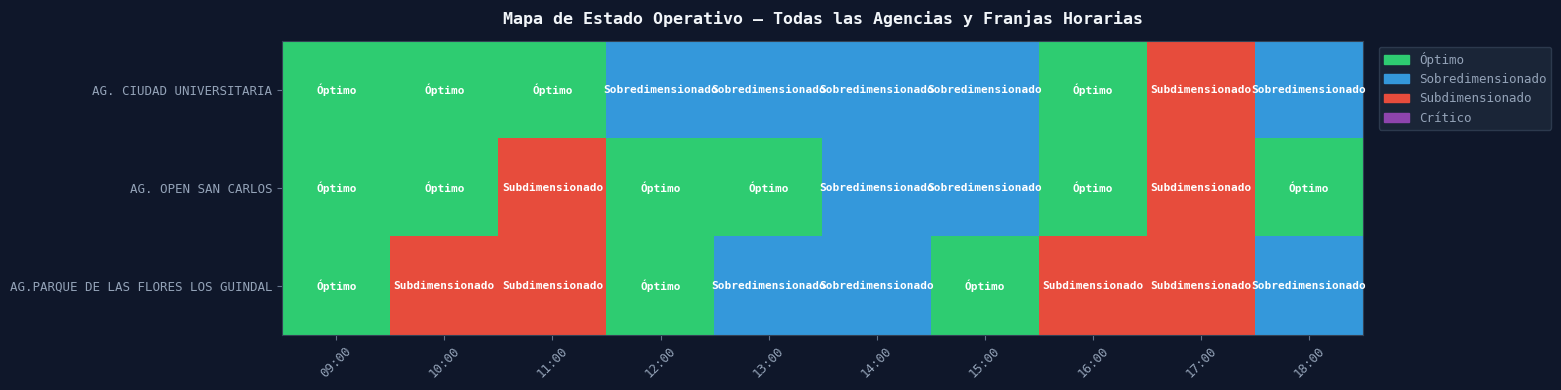

✅ Guardado: g5_mapa_estado_operativo.png


In [ ]:
fig, ax = plt.subplots(figsize=(16, 4))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#1e293b')

estado_num = {'Óptimo': 0, 'Sobredimensionado': 1, 'Subdimensionado': 2, 'Crítico': 3}
estado_colors_list = ['#2ecc71', '#3498db', '#e74c3c', '#8e44ad']
from matplotlib.colors import ListedColormap
cmap = ListedColormap(estado_colors_list)

pivot = df_final.pivot(index='agencia', columns='hora', values='estado')
pivot_num = pivot.apply(lambda col: col.map(lambda x: estado_num.get(x, -1)))
# pivot_num = pivot.applymap(lambda x: estado_num.get(x, -1))

im = ax.imshow(pivot_num.values, cmap=cmap, vmin=-0.5, vmax=3.5, aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, fontsize=9, color='#94a3b8')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([a[:35] for a in pivot.index], fontsize=9, color='#94a3b8')

for i in range(pivot_num.shape[0]):
    for j in range(pivot_num.shape[1]):
        val = pivot.values[i, j]
        ax.text(j, i, val, ha='center', va='center', fontsize=8, color='white', fontweight='bold')

patches = [mpatches.Patch(color=v, label=k) for k, v in zip(estado_num.keys(), estado_colors_list)]
ax.legend(handles=patches, loc='upper right', bbox_to_anchor=(1.18, 1), fontsize=9, framealpha=0.8)
ax.set_title('Mapa de Estado Operativo — Todas las Agencias y Franjas Horarias', fontsize=12, fontweight='bold', color='#f1f5f9', pad=12)

plt.tight_layout()
plt.savefig('g5_mapa_estado_operativo.png', dpi=130, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print('✅ Guardado: g5_mapa_estado_operativo.png')

---
## ✅ Resumen del MVP

| Componente | Descripción | Estado |
|---|---|---|
| **M/M/s** | Función reutilizada del Modelo v4, sin modificación | ✅ |
| **Optimización** | Búsqueda del mínimo s que cumple ρ < 0.85 y Wq ≤ 5 min | ✅ |
| **Clasificación** | Óptimo / Sobredimensionado / Subdimensionado / Crítico | ✅ |
| **DataFrame** | 20 variables operativas por (agencia, hora) | ✅ |
| **Visualizaciones** | 5 gráficos gerenciales exportados como PNG | ✅ |
| **Turnos** | Consolidación T1 (09-14) y T2 (14-18) con decisión | ✅ |
| **Insights** | Sobrecapacidad, subcapacidad, cuellos de botella | ✅ |
| **Power BI** | CSV + Excel por hora y turno con columnas de métricas | ✅ |
| **M/G/s** | Excluido del MVP | ❌ |
| **Monte Carlo** | Excluido del MVP | ❌ |
| **Sensibilidad** | Excluido del MVP | ❌ |